In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Fourier Transform
Un segnale può essere rappresentato come una somma pesata di seni e coseni. Questa rappresentazione si chiama serie di Fourier. La trasformata di Fourier permette di descrivere funzioni non periodiche e di passare dal dominio del tempo a quello delle frequenze (o viceversa). 
La formula: $$F(\omega)= \int_{-\infty}^{+\infty}f(t) e^{-j 2\pi \omega t} dt$$

# DFT
Quando si passa all'elaborazione digitale si lavora con funzioni campionate. Consideriamo $f(t)$ campionata con N campioni equidistanti: chiamiamo $f[n]$ l'array che contiene i valori campionati. Possiamo considerare $f[n]$ una funzione discreta e finita con N campioni. Dobbiamo renderla periodica nell'intervallo [0, T].
La DFT permette di trasformare i campioni $f[n]$ in coefficienti $F[k]$ nel dominio delle frequenze.
La sua formula è la seguente:

$$F[k]= \sum_{n=0}^{N-1}f[n] e^{-j{{2\pi}\over N }kn}$$


## Costruzione del segnale
Andiamo a impostare i parametri temporali, costruiamo un asse dei tempi e una funziona formata dalla somma di sinusoidi


Sampling interval 0.01
Sampling frequency 100.0
Array size 300


Text(0, 0.5, 'y')

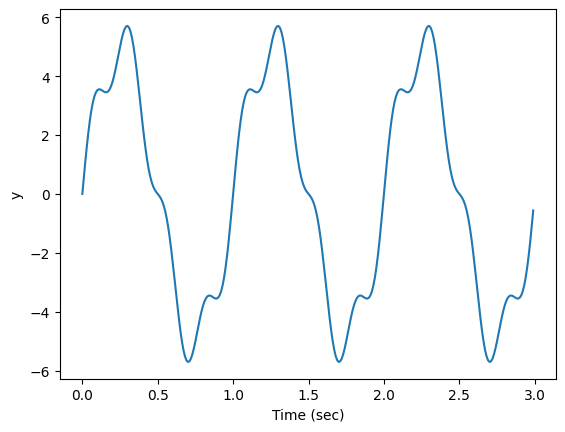

In [3]:
delta_s = 1./100 # intervallo di campionamento
f_s = 1./delta_s # Frequenza di campionamento in Hz
print("Sampling interval", delta_s)
print("Sampling frequency", f_s)

f = 1.0 # Frequenza base del segnale (1 Hz)
T = 3.0 # Durata totale dell'osservazione (3 secondi)

time = np.arange(0.0, T, delta_s)
N = time.size # numero dei campioni
print("Array size", N)

# COSTRUZIONE DI UNA FUNZIONE DISPARI (usando i seni)
y = 5 * np.sin(2 * np.pi * f * time) + 1 * np.sin(4 * 2 * np.pi * f * time)

# COSTRUZIONE DI UNA FUNZIONE PARI (usando i coseni - all'esame prova a scommentarla!)
# y = 5 * np.cos(2 * np.pi * f * time) + 1 * np.cos(10 * 2 * np.pi * f * time) + 1 * np.cos(3 * 2 * np.pi * f * time)

# Plottiamo il risultato
plt.plot(time, y)
plt.xlabel("Time (sec)")
plt.ylabel("y")

### Calcolare la DFT

Usando la libreria ${\tt numpy}$, calcoleremo:
<ul>
    <li>la DFT</li>
    <li>il suo corrispondente vettore delle frequenze </li>
    <li>la DFT inversa (per tornare al segnale)</li>
</ul>


I valori nel risultato seguono il cosiddetto ordine "standard": se A = fft(a, n), allora A[0] contiene il termine a frequenza zero (la somma del segnale), che è sempre puramente reale per input reali. Successivamente, A[1:n/2] contiene i termini a frequenza positiva, e A[n/2+1:] contiene i termini a frequenza negativa, in ordine di frequenza negativa decrescente.

La funzione np.fft.fftfreq(n) restituisce un array che fornisce le frequenze degli elementi corrispondenti nell'output.

In [ ]:
fft_y = np.fft.fft(y) # Calcola le ampiezze complesse per ogni frequenza
n = len(fft_y)
print(n)
freq = np.fft.fftfreq(n, 1/f_s)

# 0 frequency term
print("F[0]=",fft_y[0])

300
F[0]= (-9.95180269466372e-15+0j)


La funzione np.abs calcola il valore assoluto elemento per elemento. Per un input complesso, $a + ib$, il valore assoluto è <I> reale </I>: $\sqrt{ a^2 + b^2 }$.
    
    

### Plotting the DFT   
Il valore assoluto incorpora l'ampiezza (o magnitudo) di ciascuna componente in frequenza presente nel segnale.

(-9.95180269466372e-15+0j)


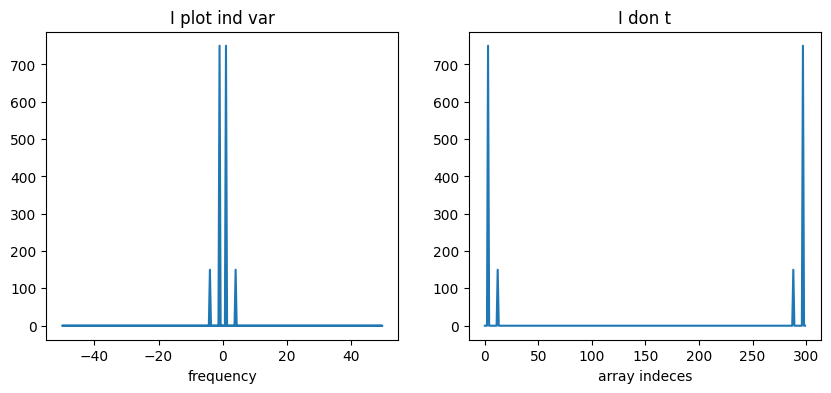

In [8]:
#primo grafico
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(freq,np.abs(fft_y))
plt.xlabel('frequency')
plt.title("I plot ind var")

# secondo grafico
plt.subplot(1,2,2)
plt.plot(np.abs(fft_y))
plt.xlabel('array indeces')
plt.title('I don t')

print (fft_y[0])

## Componente Reale e Immaginaria

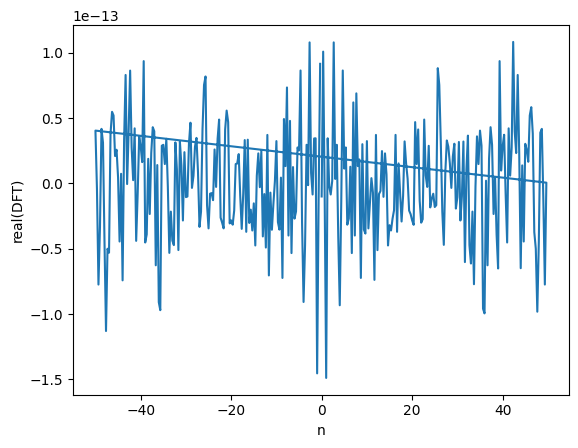

In [9]:
#real component
#coseno
R=np.real(fft_y)
plt.xlabel('n')
plt.ylabel("real(DFT)")
plt.plot(freq,R)

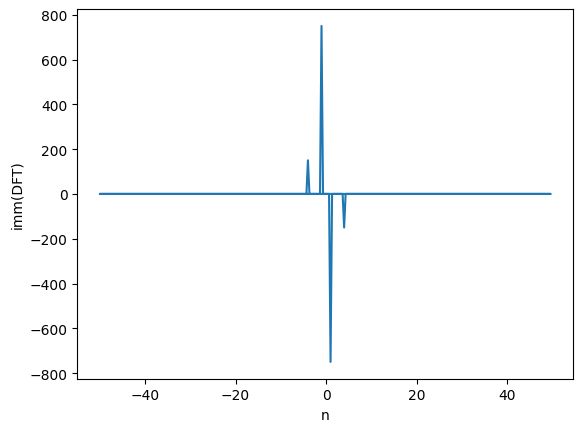

In [ ]:
#imag component
#seno
Im=np.imag(fft_y)
plt.xlabel('n')
plt.ylabel("imm(DFT)")
plt.plot(freq,Im)